
Suhaila PT
##Module 2 end Assesment

In [13]:
from google.colab import files
uploaded = files.upload()

Saving ABC Company.csv to ABC Company (1).csv


In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#load dataset
df = pd.read_csv('ABC Company.csv')
df.head(11)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0
5,Amir Johnson,Boston Celtics,90,PF,29,06-Sep,240,NaN,12000000.0
6,Jordan Mickey,Boston Celtics,55,PF,21,06-Aug,235,LSU,1170960.0
7,Kelly Olynyk,Boston Celtics,41,C,25,7-0,238,Gonzaga,2165160.0
8,Terry Rozier,Boston Celtics,12,PG,22,06-Feb,190,Louisville,1824360.0
9,Marcus Smart,Boston Celtics,36,PG,22,06-Apr,220,Oklahoma State,3431040.0


In [15]:
df.shape

(458, 9)

In [16]:
df.dtypes

,0
Name,object
Team,object
Number,int64
Position,object
Age,int64
Height,object
Weight,int64
College,object
Salary,float64


##Preprossessing:
Correct the data in the "height" column by replacing it with random
numbers between 150 and 180. Ensure data consistency and integrity
before proceeding with analysis.

In [17]:
df['Height']=np.random.randint(150,180,size=len(df))
df.head()


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,165,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,169,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,161,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,176,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,157,231,NaN,5000000.0


In [18]:
#checking if there is any missing value
df.isnull().sum()

,0
Name,0
Team,0
Number,0
Position,0
Age,0
Height,0
Weight,0
College,84
Salary,11


---

##Analysis Tasks:

---

a: Determine the distribution of employees across each team and calculate
the percentage split relative to the total number of employees.

In [19]:
df['Team'].value_counts()

,count
Team,
New Orleans Pelicans,19
Memphis Grizzlies,18
Utah Jazz,16
Milwaukee Bucks,16
New York Knicks,16
Boston Celtics,15
Los Angeles Clippers,15
Los Angeles Lakers,15
Phoenix Suns,15


In [20]:
print("Team percentage")
print()

df['Team'].value_counts(normalize=True) *100

Team percentage



,proportion
Team,
New Orleans Pelicans,4.148472
Memphis Grizzlies,3.930131
Utah Jazz,3.493450
Milwaukee Bucks,3.493450
New York Knicks,3.493450
Boston Celtics,3.275109
Los Angeles Clippers,3.275109
Los Angeles Lakers,3.275109
Phoenix Suns,3.275109


In [21]:
#which team has highest total salary
print("Team with highest total salary")
print()

team_salary = df.groupby('Team')['Salary'].sum()
print(team_salary.idxmax())
#how many employees
print(team_salary.max())

Team with highest total salary

Cleveland Cavaliers
106988689.0


In [22]:
# which team has lowest total salary
print("Team with lowest total salary")
print()

print(team_salary.idxmin())

print(team_salary.min())

Team with lowest total salary

Philadelphia 76ers
30992894.0


b: Segregate employees based on their positions within the company.

In [23]:
print("Number of embloyees based on their position:")
print()
position_counts = df['Position'].value_counts()
print(position_counts)

Number of embloyees based on their position:

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


In [24]:
print ("Most common job role:")
print(df['Position'].value_counts().idxmax())
df['Position'].value_counts().max()


Most common job role:
SG


102

In [25]:
print("least common job role:")
print(df['Position'].value_counts().idxmin())
df['Position'].value_counts().min()

least common job role:
C


79

c: Identify the predominant age group among employees.

In [26]:
bins = [0, 18, 25, 30, 35, 40, 45]
labels = ['<18', '18-24', '25-29', '30-34', '35-39', '40-44']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

print('Predominant age group:')
print(df['Age_group'].value_counts())
print('\nMost frequent age group:')
print(df['Age_group'].value_counts().idxmax())

Predominant age group:
Age_group
25-29    182
18-24    154
30-34     90
35-39     29
40-44      3
<18        0
Name: count, dtype: int64

Most frequent age group:
25-29


d: Discover which team and position have the highest salary expenditure.


In [27]:
print('Team and Position with highest salary expenditure:')
highest_expenditure = df.groupby(['Team', 'Position'])['Salary'].sum()
print(highest_expenditure.idxmax())
print(highest_expenditure.max())

Team and Position with highest salary expenditure:
('Los Angeles Lakers', 'SF')
31866445.0


e: Investigate if there's any correlation between age and salary, and
represent it visually.


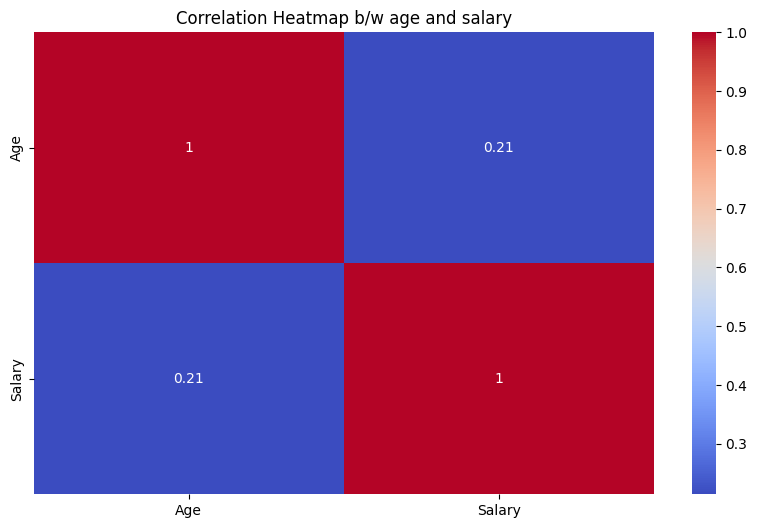

In [28]:
temp_df = df[['Age', 'Salary']]
correlation = temp_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap b/w age and salary')
plt.show()

---

#graphical representation

---





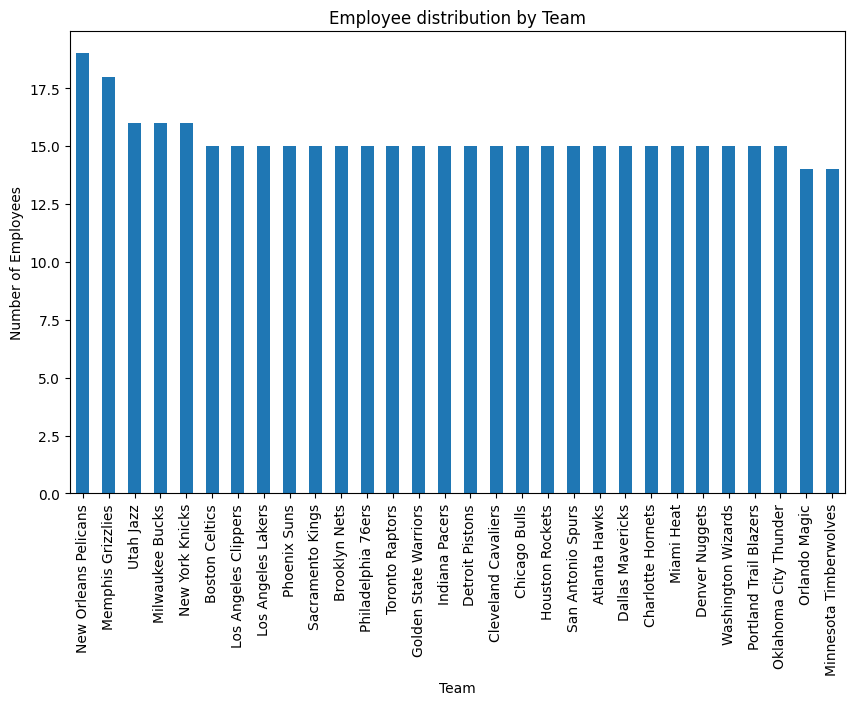

In [29]:
#visual representaion of employee by team
team_counts = df['Team'].value_counts()
plt.figure(figsize=(10,6))
team_counts.plot(kind='bar')
plt.title('Employee distribution by Team')
plt.xlabel('Team')
plt.ylabel('Number of Employees')
plt.show()

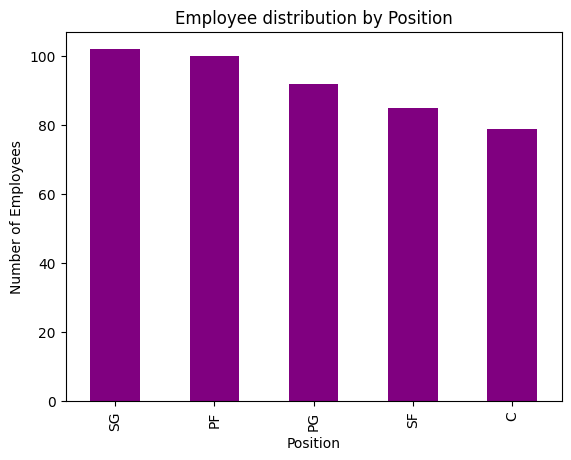

In [30]:
#visual representatioin of employee count by position
plt.figure()
position_counts = df['Position'].value_counts()
position_counts.plot(kind='bar',color="purple")
plt.title('Employee distribution by Position')
plt.xlabel('Position')
plt.ylabel('Number of Employees')
plt.show()

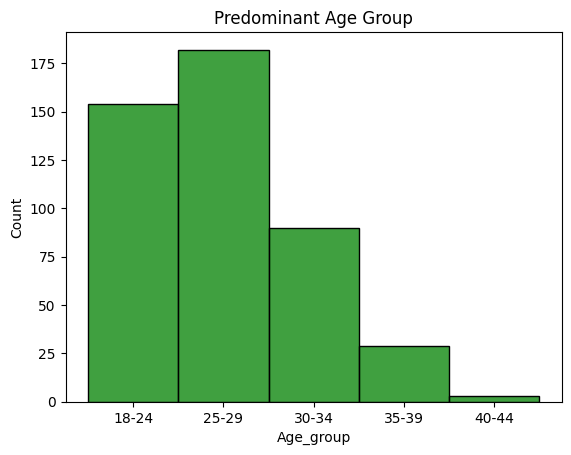

In [31]:
#visual representation of predominant age group
sns.histplot(data=df,x='Age_group',color='green')
plt.title('Predominant Age Group')
plt.show()

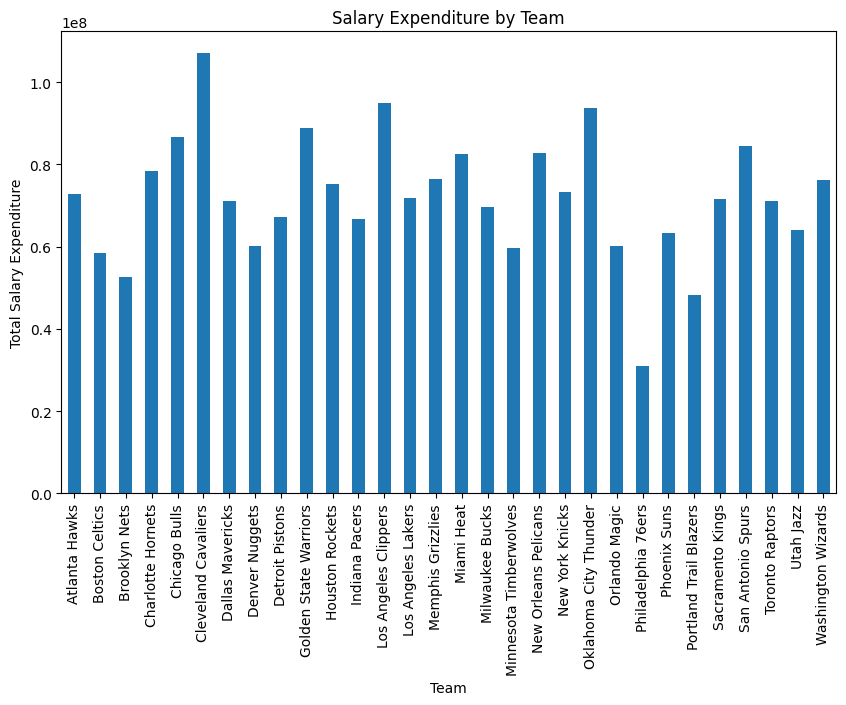

In [32]:
#visual representation of salary expenditure by team
team_salary = df.groupby('Team')['Salary'].sum()
plt.figure(figsize=(10,6))
team_salary.plot(kind='bar')
plt.title('Salary Expenditure by Team')
plt.xlabel('Team')
plt.ylabel('Total Salary Expenditure')
plt.show()

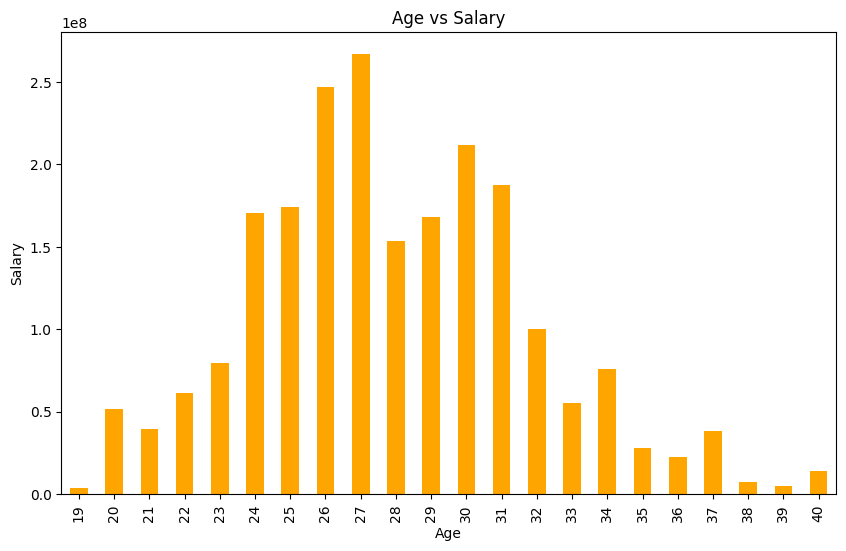

In [33]:

#Age vs salary
Age_group = df.groupby('Age')['Salary'].sum()
plt.figure(figsize=(10,6))
Age_group.plot(kind='bar',color='orange')
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()



## DATA STORY


---
In this project analyzes an employee dataset containing 458 records with multiple teams and positions within the organisation. The objective of this analysis is to understand work distribution, salary expenditure, predominant age groups and relation between age and salary.

### Key insights from the Analysis

> The majority of employees belongs to "New Orleans Pelicans" team.

> The least number of employees are in "Orlando Magic" team.

> Team with highest total salary is "Cleveland Cavaliers".

> Team with lowest total salary is "Philadelphia 76ers".

> The most common positions in the company is from 'SG'.

> The least common  job position in the company is from 'C'.

> The majority of employees fall within the 25-30 age group.

> The 'Los Angeles Lakers' team and 'SF' position contributes has the highest total salary expenditure cost 31866445.0  .

> The correation between  Age and Salary is 0.21, which indicates a weak positive reationship.

  It means:
     
*   salary trends to increase slightly as age increases.
*   However,age alone doesn't strongly determine salary.



---